<a href="https://colab.research.google.com/github/Optimus0205/ProcDna-Case-Study/blob/main/Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ques 1

##Who are the most active doctors and are they helping our product?

## Top 10 by alert volume

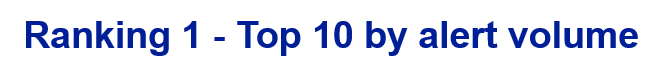
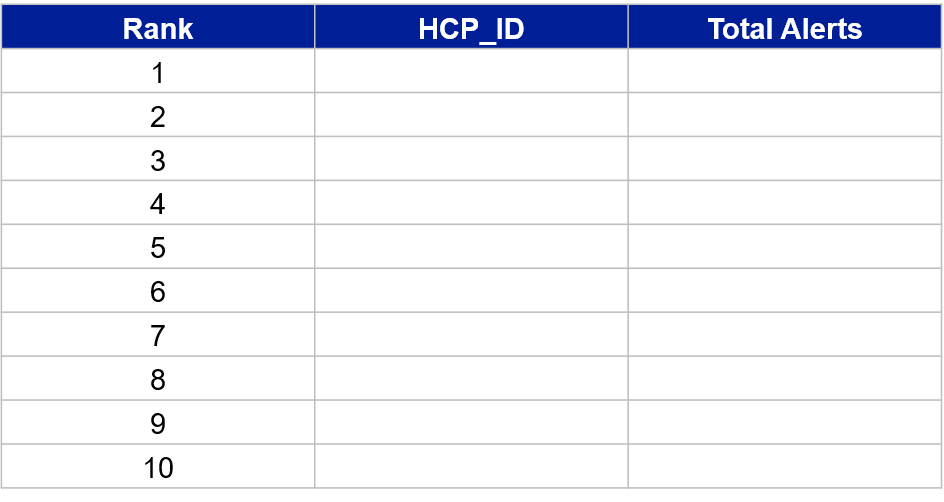

In [1]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv('/content/PrimeRx Datasets Alerts.csv')
df.head()

,Alert_ID,Alert_Date,HCP_ID,Lab_Result
0,ALT001134,3/7/2024,HCP009,Negative
1,ALT008550,10/15/2024,HCP109,Negative
2,ALT008560,7/1/2023,HCP110,Positive
3,ALT006177,12/4/2023,HCP045,Negative
4,ALT008377,7/1/2023,HCP105,Positive


In [4]:
df['HCP_ID'].unique()

array(['HCP009', 'HCP109', 'HCP110', 'HCP045', 'HCP105', 'HCP064',
       'HCP075', 'HCP003', 'HCP021', 'HCP026', 'HCP103', 'HCP037',
       'HCP017', 'HCP004', 'HCP035', 'HCP011', 'HCP044', 'HCP204',
       'HCP029', 'HCP007', 'HCP030', 'HCP177', 'HCP027', 'HCP041',
       'HCP081', 'HCP001', 'HCP052', 'HCP036', 'HCP090', 'HCP086',
       'HCP006', 'HCP043', 'HCP061', 'HCP055', 'HCP042', 'HCP119',
       'HCP132', 'HCP018', 'HCP005', 'HCP031', 'HCP010', 'HCP100',
       'HCP174', 'HCP066', 'HCP019', 'HCP220', 'HCP025', 'HCP008',
       'HCP097', 'HCP096', 'HCP104', 'HCP143', 'HCP130', 'HCP028',
       'HCP146', 'HCP197', 'HCP059', 'HCP073', 'HCP060', 'HCP056',
       'HCP046', 'HCP020', 'HCP070', 'HCP202', 'HCP152', 'HCP057',
       'HCP206', 'HCP032', 'HCP091', 'HCP013', 'HCP147', 'HCP034',
       'HCP203', 'HCP014', 'HCP150', 'HCP201', 'HCP002', 'HCP040',
       'HCP038', 'HCP033', 'HCP051', 'HCP067', 'HCP158', 'HCP022',
       'HCP069', 'HCP015', 'HCP089', 'HCP194', 'HCP135', 'HCP0

In [5]:
top_active_doctors = df['HCP_ID'].value_counts().head(10)
top_active_doctors

,count
HCP_ID,
HCP041,200
HCP011,198
HCP019,190
HCP020,188
HCP032,188
HCP021,185
HCP014,178
HCP036,176
HCP022,175


In [8]:
top_active_doctors = top_active_doctors.reset_index(name='Total Alerts')
top_active_doctors

,HCP_ID,Total Alerts
0,HCP041,200
1,HCP011,198
2,HCP019,190
3,HCP020,188
4,HCP032,188
5,HCP021,185
6,HCP014,178
7,HCP036,176
8,HCP022,175
9,HCP007,173


# Ques 1-2

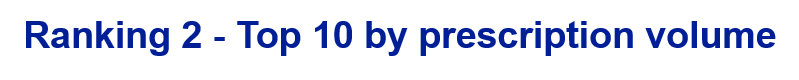


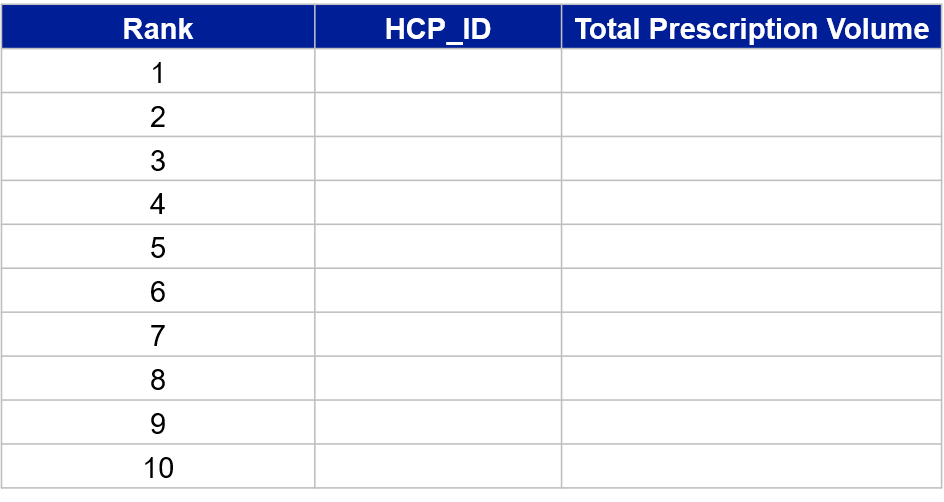

In [10]:
df1=pd.read_excel('/content/PrimeRx Datasets.xlsx', sheet_name='Sales')
df1.head()

,Prescription_ID,Prescription_Date,HCP_ID,Drug_Name,Drug_ID,Prescription_Volume
0,RX004327,2024-12-31,HCP159,Rivalex,DRG002,22
1,RX005835,2024-12-31,HCP217,Rivalex,DRG002,46
2,RX004207,2024-12-31,HCP156,Nexavir,DRG001,27
3,RX004120,2024-12-31,HCP154,Rivalex,DRG002,44
4,RX002489,2024-12-31,HCP095,Nexavir,DRG001,17


In [11]:
df1_agg = df1.groupby('HCP_ID')['Prescription_Volume'].sum().reset_index().sort_values(by='Prescription_Volume', ascending=False)
df1_agg.head(10)

,HCP_ID,Prescription_Volume
146,HCP185,2900
45,HCP062,2380
12,HCP019,2277
129,HCP163,2233
99,HCP126,2196
167,HCP211,2196
122,HCP154,2187
171,HCP215,2155
68,HCP088,2084
1,HCP004,2081


In [21]:
df1_agg_renamed = df1_agg.rename(columns={'Prescription_Volume': 'Total_Prescription_Volume'})
df_ranked = df1_agg_renamed.head(10).reset_index(drop=True)
df_ranked.insert(0, 'Rank', range(1, 1 + len(df_ranked)))
df_ranked

,Rank,HCP_ID,Total_Prescription_Volume
0,1,HCP185,2900
1,2,HCP062,2380
2,3,HCP019,2277
3,4,HCP163,2233
4,5,HCP126,2196
5,6,HCP211,2196
6,7,HCP154,2187
7,8,HCP215,2155
8,9,HCP088,2084
9,10,HCP004,2081


# Ques 2

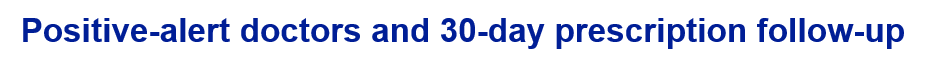


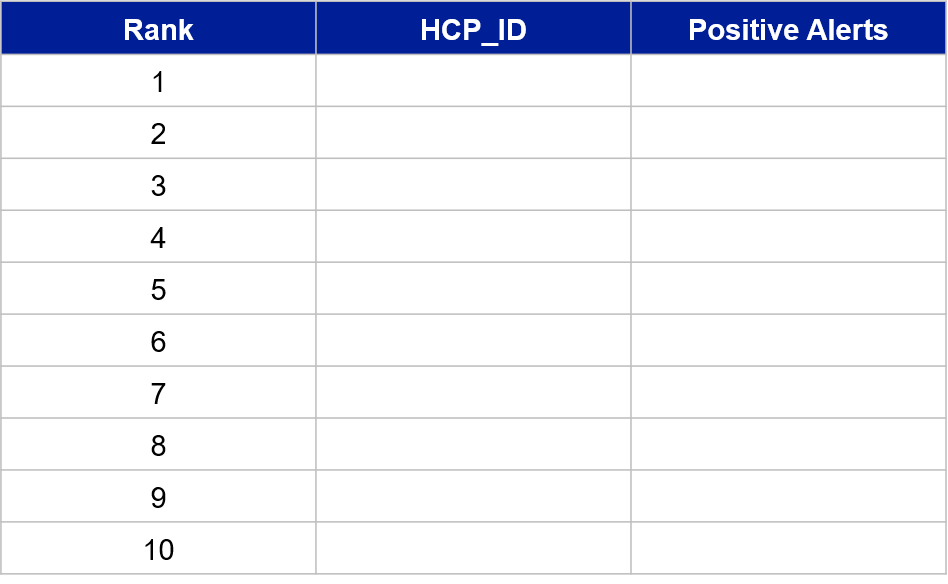

In [ ]:
# Merge df and df1 on 'HCP_ID'
df2 = pd.merge(df, df1, on='HCP_ID', how='inner')
df2.head()

,Alert_ID,Alert_Date,HCP_ID,Lab_Result,Prescription_ID,Prescription_Date,Drug_Name,Drug_ID,Prescription_Volume
0,ALT008560,7/1/2023,HCP110,Positive,RX002927,2024-12-04,Rivalex,DRG002,28
1,ALT008560,7/1/2023,HCP110,Positive,RX002926,2024-11-28,Omniphar,DRG003,19
2,ALT008560,7/1/2023,HCP110,Positive,RX002925,2024-10-22,Omniphar,DRG003,26
3,ALT008560,7/1/2023,HCP110,Positive,RX002924,2024-10-20,Omniphar,DRG003,56
4,ALT008560,7/1/2023,HCP110,Positive,RX002923,2024-10-18,Rivalex,DRG002,33


In [ ]:
(df2['Lab_Result'] == 'Positive') | (df2['Drug_Name'] == 'Nexavir')

,0
0,True
1,True
2,True
3,True
4,True
...,...
253669,True
253670,True
253671,True
253672,False


In [ ]:
filtered_df2 = df2[(df2['Lab_Result'] == 'Positive') | (df2['Drug_Name'] == 'Nexavir')]
display(filtered_df2.head())

,Alert_ID,Alert_Date,HCP_ID,Lab_Result,Prescription_ID,Prescription_Date,Drug_Name,Drug_ID,Prescription_Volume
0,ALT008560,7/1/2023,HCP110,Positive,RX002927,2024-12-04,Rivalex,DRG002,28
1,ALT008560,7/1/2023,HCP110,Positive,RX002926,2024-11-28,Omniphar,DRG003,19
2,ALT008560,7/1/2023,HCP110,Positive,RX002925,2024-10-22,Omniphar,DRG003,26
3,ALT008560,7/1/2023,HCP110,Positive,RX002924,2024-10-20,Omniphar,DRG003,56
4,ALT008560,7/1/2023,HCP110,Positive,RX002923,2024-10-18,Rivalex,DRG002,33


In [ ]:
df2[(df2['Lab_Result'] == 'Positive') & (df2['Drug_Name'] == 'Nexavir')]

,Alert_ID,Alert_Date,HCP_ID,Lab_Result,Prescription_ID,Prescription_Date,Drug_Name,Drug_ID,Prescription_Volume
8,ALT008560,7/1/2023,HCP110,Positive,RX002919,2024-09-19,Nexavir,DRG001,32
13,ALT008560,7/1/2023,HCP110,Positive,RX002914,2024-08-04,Nexavir,DRG001,17
16,ALT008560,7/1/2023,HCP110,Positive,RX002911,2024-04-03,Nexavir,DRG001,54
45,ALT008377,7/1/2023,HCP105,Positive,RX002789,2024-02-25,Nexavir,DRG001,19
57,ALT007259,7/1/2023,HCP075,Positive,RX001917,2024-11-21,Nexavir,DRG001,23
...,...,...,...,...,...,...,...,...,...
253479,ALT001951,12/31/2024,HCP014,Positive,RX000337,2024-02-21,Nexavir,DRG001,46
253484,ALT001951,12/31/2024,HCP014,Positive,RX000332,2023-09-17,Nexavir,DRG001,43
253485,ALT001951,12/31/2024,HCP014,Positive,RX000331,2023-07-29,Nexavir,DRG001,52
253487,ALT001951,12/31/2024,HCP014,Positive,RX000329,2023-07-21,Nexavir,DRG001,48


In [ ]:
# Convert date columns to datetime objects
df2['Alert_Date'] = pd.to_datetime(df2['Alert_Date'])
df2['Prescription_Date'] = pd.to_datetime(df2['Prescription_Date'])

# Calculate the absolute difference in days between the dates
df2['Date_Difference_Days'] = (df2['Prescription_Date'] - df2['Alert_Date']).dt.days

# Filter for rows where the absolute difference is within 30 days
# (i.e., -30 <= Date_Difference_Days <= 30)
df2 = df2[df2['Date_Difference_Days'].abs() <= 30]

df2=df2[(df2['Lab_Result'] == 'Positive') & (df2['Drug_Name'] == 'Nexavir')].sort_values(by='Date_Difference_Days',ascending=False)
df2
#df2.sort_values(by='Prescription_Volume',ascending=False)


,Alert_ID,Alert_Date,HCP_ID,Lab_Result,Prescription_ID,Prescription_Date,Drug_Name,Drug_ID,Prescription_Volume,Date_Difference_Days
195064,ALT002545,2024-08-30,HCP019,Positive,RX000507,2024-09-29,Nexavir,DRG001,36,30
10281,ALT008279,2023-07-24,HCP103,Positive,RX002693,2023-08-23,Nexavir,DRG001,56,30
85256,ALT005175,2024-01-01,HCP037,Positive,RX001036,2024-01-31,Nexavir,DRG001,45,30
23108,ALT001967,2023-08-24,HCP015,Positive,RX000356,2023-09-23,Nexavir,DRG001,26,30
23362,ALT008430,2023-08-24,HCP106,Positive,RX002809,2023-09-23,Nexavir,DRG001,35,30
...,...,...,...,...,...,...,...,...,...,...
37738,ALT005271,2023-09-23,HCP038,Positive,RX001069,2023-08-24,Nexavir,DRG001,35,-30
163069,ALT001740,2024-06-25,HCP013,Positive,RX000314,2024-05-26,Nexavir,DRG001,15,-30
217579,ALT007892,2024-10-14,HCP091,Positive,RX002405,2024-09-14,Nexavir,DRG001,31,-30
247869,ALT005249,2024-12-19,HCP037,Positive,RX001055,2024-11-19,Nexavir,DRG001,9,-30


In [ ]:
# Convert date columns to datetime objects
df2['Alert_Date'] = pd.to_datetime(df2['Alert_Date'])
df2['Prescription_Date'] = pd.to_datetime(df2['Prescription_Date'])

# Calculate the absolute difference in days between the dates
df2['Date_Difference_Days'] = (df2['Prescription_Date'] - df2['Alert_Date']).dt.days

# Filter for rows where the absolute difference is within 30 days
# (i.e., -30 <= Date_Difference_Days <= 30)
df2 = df2[df2['Date_Difference_Days'].abs() <= 30]

df2=df2[(df2['Lab_Result'] == 'Positive') & (df2['Drug_Name'] == 'Nexavir')].sort_values(by='Date_Difference_Days',ascending=False)
df2
df2['HCP_ID'].value_counts().head(10)

,count
HCP_ID,
HCP032,425
HCP036,378
HCP038,325
HCP019,283
HCP022,251
HCP012,241
HCP004,234
HCP016,217
HCP033,215


### Identify doctors with positive lab alerts and their first positive alert date

In [ ]:
df['Alert_Date'] = pd.to_datetime(df['Alert_Date'])
positive_alerts_df = df[df['Lab_Result'] == 'Positive']
first_positive_alert_date = positive_alerts_df.groupby('HCP_ID')['Alert_Date'].min().reset_index()
first_positive_alert_date.rename(columns={'Alert_Date': 'First_Positive_Alert_Date'}, inplace=True)
display(first_positive_alert_date.head())

,HCP_ID,First_Positive_Alert_Date
0,HCP001,2023-07-02
1,HCP002,2023-07-09
2,HCP003,2023-07-12
3,HCP004,2023-07-01
4,HCP005,2023-07-05


### Check for prescription activity within 30 days of the first positive alert

In [ ]:
df1['Prescription_Date'] = pd.to_datetime(df1['Prescription_Date'])

# Merge first positive alert date with sales data
merged_df = pd.merge(first_positive_alert_date, df1, on='HCP_ID', how='inner')

# Calculate the difference between prescription date and first positive alert date
merged_df['Date_Difference_Days'] = (merged_df['Prescription_Date'] - merged_df['First_Positive_Alert_Date']).dt.days

# Filter for prescriptions within 30 days after the first positive alert (0 to 30 days inclusive)
prescription_activity_30_days = merged_df[(merged_df['Date_Difference_Days'] >= 0) & (merged_df['Date_Difference_Days'] <= 30)]

# Identify HCPs with prescription activity within 30 days
hcps_with_prescription_activity = prescription_activity_30_days['HCP_ID'].unique()

display(prescription_activity_30_days.head())

,HCP_ID,First_Positive_Alert_Date,Prescription_ID,Prescription_Date,Drug_Name,Drug_ID,Prescription_Volume,Date_Difference_Days
48,HCP003,2023-07-12,RX000003,2023-07-22,Nexavir,DRG001,52,10
49,HCP003,2023-07-12,RX000002,2023-07-17,Nexavir,DRG001,44,5
50,HCP003,2023-07-12,RX000001,2023-07-16,Nexavir,DRG001,20,4
117,HCP004,2023-07-01,RX000054,2023-07-28,Nexavir,DRG001,9,27
118,HCP004,2023-07-01,RX000053,2023-07-18,Omniphar,DRG003,42,17


### Identify doctors with no prescribing activity within the 30-day window

In [ ]:
# Get all HCPs who had at least one positive alert
all_hcps_with_positive_alerts = first_positive_alert_date['HCP_ID'].unique()

# Find HCPs with positive alerts but no prescription activity within 30 days
hcps_no_prescription_after_alert = [
    hcp for hcp in all_hcps_with_positive_alerts
    if hcp not in hcps_with_prescription_activity
]

print(f"Number of HCPs with positive alerts and no prescription activity within 30 days: {len(hcps_no_prescription_after_alert)}")
print("Example HCPs with no prescription activity after alert:", hcps_no_prescription_after_alert[:10])

Number of HCPs with positive alerts and no prescription activity within 30 days: 77
Example HCPs with no prescription activity after alert: ['HCP001', 'HCP002', 'HCP007', 'HCP009', 'HCP011', 'HCP017', 'HCP021', 'HCP023', 'HCP024', 'HCP026']


### Rank Top 10 HCPs by total positive alert volume (for those with no prescribing activity)

# 2

In [ ]:
# Filter the original positive alerts DataFrame for HCPs with no prescribing activity
docs_to_rank_df = positive_alerts_df[positive_alerts_df['HCP_ID'].isin(hcps_no_prescription_after_alert)]

# Count the total positive alert volume for these HCPs
top_10_hcps_no_activity = docs_to_rank_df['HCP_ID'].value_counts().head(10)

print("Top 10 HCPs with Positive Alerts and No Prescribing Activity (ranked by alert volume):")
display(top_10_hcps_no_activity)

Top 10 HCPs with Positive Alerts and No Prescribing Activity (ranked by alert volume):


,count
HCP_ID,
HCP041,127
HCP011,123
HCP021,116
HCP042,101
HCP023,99
HCP007,96
HCP026,78
HCP009,67
HCP001,63


### Funnel Analysis: HCPs with Positive Alerts to No Prescribing Activity

# 2-2

In [ ]:
# Stage 1: HCPs with at least one positive alert
num_hcps_one_plus_alert = len(all_hcps_with_positive_alerts)
print(f"Number of HCPs with at least one positive alert: {num_hcps_one_plus_alert}")

# Stage 2: HCPs with multiple positive alerts (more than one alert)
positive_alert_counts = positive_alerts_df['HCP_ID'].value_counts()
hcps_multiple_positive_alerts = positive_alert_counts[positive_alert_counts > 1].index.tolist()
num_hcps_multiple_alerts = len(hcps_multiple_positive_alerts)
print(f"Number of HCPs with multiple positive alerts: {num_hcps_multiple_alerts}")

# Stage 3: HCPs with multiple positive alerts AND no prescribing activity within 30 days
hcps_multiple_alerts_no_rx = [hcp for hcp in hcps_multiple_positive_alerts if hcp in hcps_no_prescription_after_alert]
num_hcps_multiple_alerts_no_rx = len(hcps_multiple_alerts_no_rx)
print(f"Number of HCPs with multiple positive alerts and no prescribing activity within 30 days: {num_hcps_multiple_alerts_no_rx}")

# Create a DataFrame for the funnel
funnel_data = {
    'Stage': [
        'HCPs with at least one positive alert',
        'HCPs with multiple positive alerts',
        'HCPs with multiple positive alerts & no Rx activity'
    ],
    'Count': [
        num_hcps_one_plus_alert,
        num_hcps_multiple_alerts,
        num_hcps_multiple_alerts_no_rx
    ]
}
funnel_df = pd.DataFrame(funnel_data)
display(funnel_df)

Number of HCPs with at least one positive alert: 214
Number of HCPs with multiple positive alerts: 198
Number of HCPs with multiple positive alerts and no prescribing activity within 30 days: 68


,Stage,Count
0,HCPs with at least one positive alert,214
1,HCPs with multiple positive alerts,198
2,HCPs with multiple positive alerts & no Rx act...,68


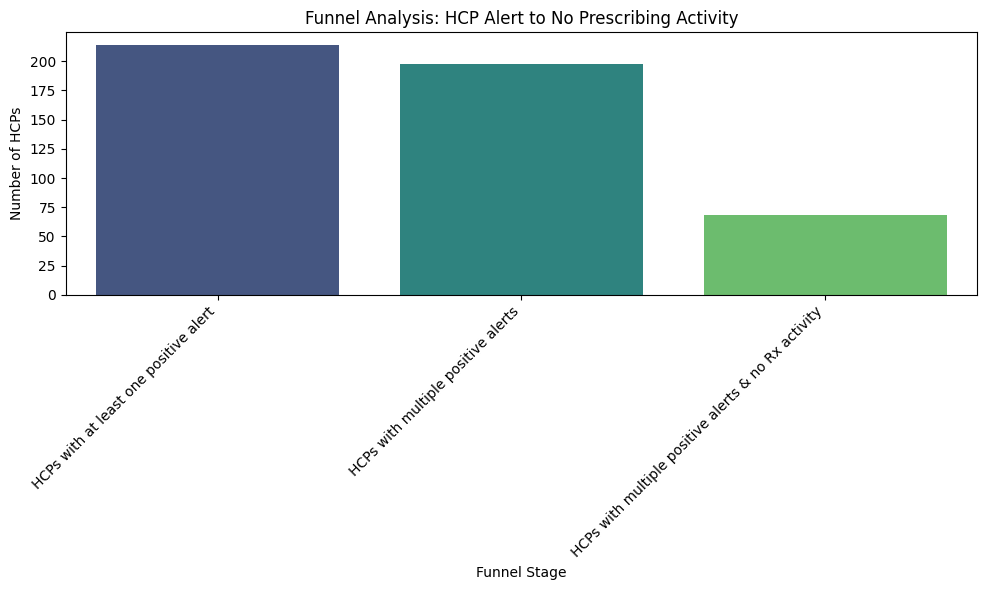

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Stage', y='Count', data=funnel_df, palette='viridis', hue='Stage', legend=False)
plt.title('Funnel Analysis: HCP Alert to No Prescribing Activity')
plt.xlabel('Funnel Stage')
plt.ylabel('Number of HCPs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Ques 6

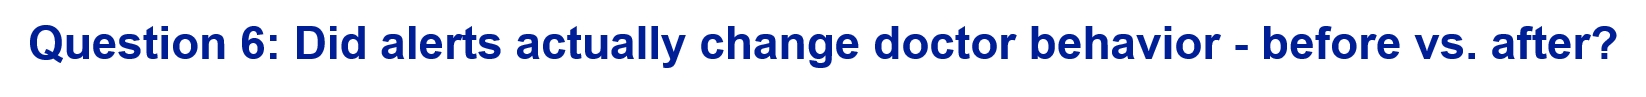

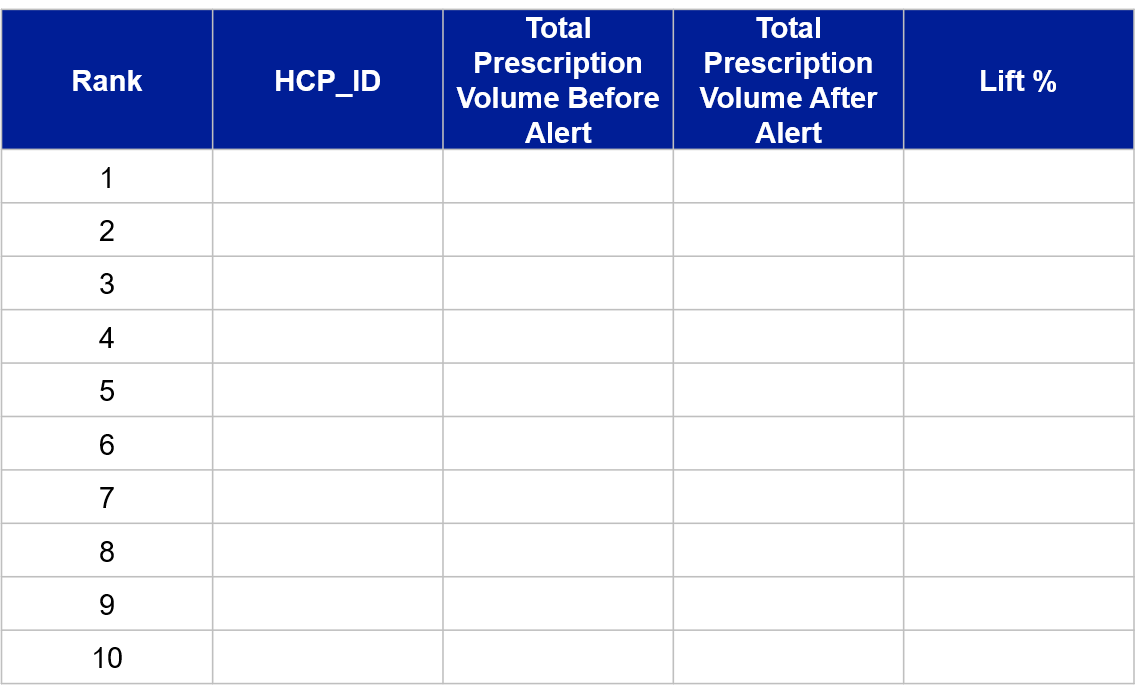

Part A - Basic lift: Define a 90-day before and 90-day after window around each doctor's first positive alert. Calculate prescription volume for our drug in each window. Rank Top 10 HCPs by lift % with highest lift being Rank 1?

In [ ]:
df2 = pd.merge(df, df1, on='HCP_ID', how='inner')

### Calculate Prescription Volume Before and After First Positive Alert

#6a

In [ ]:
# Ensure df and df1 are up-to-date and date columns are in datetime format
df['Alert_Date'] = pd.to_datetime(df['Alert_Date'])
df1['Prescription_Date'] = pd.to_datetime(df1['Prescription_Date'])

# Get the first positive alert date for each HCP
positive_alerts = df[df['Lab_Result'] == 'Positive']
first_positive_alert_date = positive_alerts.groupby('HCP_ID')['Alert_Date'].min().reset_index()
first_positive_alert_date.rename(columns={'Alert_Date': 'First_Positive_Alert_Date'}, inplace=True)

# Merge with sales data and filter for 'Nexavir' prescriptions
merged_for_lift_df = pd.merge(first_positive_alert_date, df1, on='HCP_ID', how='inner')
nexavir_prescriptions_df = merged_for_lift_df[merged_for_lift_df['Drug_Name'] == 'Nexavir']

# Calculate the date difference
nexavir_prescriptions_df['Date_Difference_Days'] = (nexavir_prescriptions_df['Prescription_Date'] - nexavir_prescriptions_df['First_Positive_Alert_Date']).dt.days

# Define before and after windows
before_window_df = nexavir_prescriptions_df[
    (nexavir_prescriptions_df['Date_Difference_Days'] >= -90) &
    (nexavir_prescriptions_df['Date_Difference_Days'] <= -1)
]

after_window_df = nexavir_prescriptions_df[
    (nexavir_prescriptions_df['Date_Difference_Days'] >= 0) &
    (nexavir_prescriptions_df['Date_Difference_Days'] <= 90)
]

# Aggregate prescription volume for each window
before_volumes = before_window_df.groupby('HCP_ID')['Prescription_Volume'].sum().reset_index()
before_volumes.rename(columns={'Prescription_Volume': 'Pre Prescription Volume'}, inplace=True)

after_volumes = after_window_df.groupby('HCP_ID')['Prescription_Volume'].sum().reset_index()
after_volumes.rename(columns={'Prescription_Volume': 'Post Prescription Volume'}, inplace=True)

# Merge before and after volumes
lift_df = pd.merge(before_volumes, after_volumes, on='HCP_ID', how='outer').fillna(0)

# Calculate Lift Percentage
# Handle division by zero for 'Before_Volume' where it's 0
lift_df['Lift_Percentage'] = lift_df.apply(
    lambda row:
        ((row['Post Prescription Volume'] - row['Pre Prescription Volume']) / row['Pre Prescription Volume'] * 100)
        if row['Pre Prescription Volume'] != 0 else
        (100 if row['Post Prescription Volume'] > 0 else 0),
    axis=1
)

# Rank by Lift Percentage
ranked_hcps_by_lift = lift_df.sort_values(by='Lift_Percentage', ascending=False).reset_index(drop=True)

display(ranked_hcps_by_lift.head(10))

/tmp/ipykernel_873/606244123.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nexavir_prescriptions_df['Date_Difference_Days'] = (nexavir_prescriptions_df['Prescription_Date'] - nexavir_prescriptions_df['First_Positive_Alert_Date']).dt.days


,HCP_ID,Pre Prescription Volume,Post Prescription Volume,Lift_Percentage
0,HCP040,8.0,143.0,1687.500000
1,HCP050,10.0,107.0,970.000000
2,HCP006,32.0,249.0,678.125000
3,HCP108,31.0,238.0,667.741935
4,HCP016,50.0,279.0,458.000000
5,HCP159,42.0,232.0,452.380952
6,HCP157,72.0,387.0,437.500000
7,HCP211,42.0,223.0,430.952381
8,HCP209,64.0,335.0,423.437500
9,HCP125,49.0,214.0,336.734694


### Categorize HCPs based on Lift Percentage

In [ ]:
# Categorize HCPs
def categorize_hcp(row):
    if row['Pre Prescription Volume'] == 0 and row['Post Prescription Volume'] > 0:
        return 'New Starter'
    elif row['Pre Prescription Volume'] > 0 and row['Lift_Percentage'] >= 20:
        return 'Grower'
    else:
        return 'Non-Responder'

lift_df['Category'] = lift_df.apply(categorize_hcp, axis=1)

# Display the categorized HCPs, focusing on the top 10 ranked by lift or relevant categories
display(lift_df.sort_values(by='Lift_Percentage', ascending=False).head(10))

,HCP_ID,Pre Prescription Volume,Post Prescription Volume,Lift_Percentage,Category
27,HCP040,8.0,143.0,1687.500000,Grower
31,HCP050,10.0,107.0,970.000000,Grower
3,HCP006,32.0,249.0,678.125000,Grower
70,HCP108,31.0,238.0,667.741935,Grower
10,HCP016,50.0,279.0,458.000000,Grower
102,HCP159,42.0,232.0,452.380952,Grower
100,HCP157,72.0,387.0,437.500000,Grower
128,HCP211,42.0,223.0,430.952381,Grower
126,HCP209,64.0,335.0,423.437500,Grower
78,HCP125,49.0,214.0,336.734694,Grower


Part B - Segment the lift: Split all doctors into 3 behavioral bucket as mentioned in the formula table. Does the lift look different across the three groups? Which group shows strongest commercial impact?

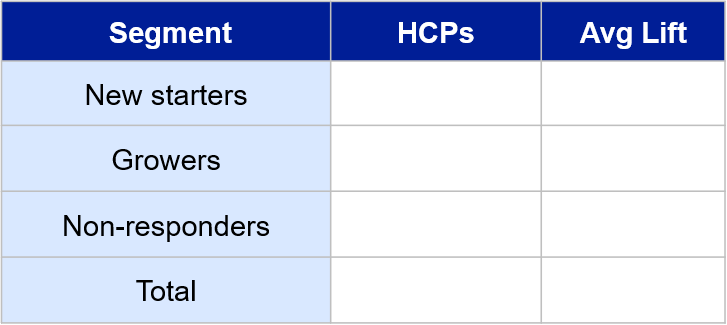

### Segmenting Doctors into Behavioral Buckets and Analyzing Lift

In [ ]:
# Calculate aggregated metrics for each category
category_impact = lift_df.groupby('Category').agg(
    mean_pre_volume=('Pre Prescription Volume', 'mean'),
    mean_post_volume=('Post Prescription Volume', 'mean'),
    mean_lift_percentage=('Lift_Percentage', 'mean'),
    count=('HCP_ID', 'count')
).reset_index()

print("Aggregated Lift Metrics by Category:")
display(category_impact.round(2))

# Identify the group with the strongest commercial impact (e.g., highest mean post-prescription volume or highest mean lift for non-zero pre-volume)
# For 'New Starters', the commercial impact is purely from the 'Post Prescription Volume'.
# For 'Growers', both 'Post Prescription Volume' and 'Lift_Percentage' are important.
# For 'Non-Responders', the impact is minimal or negative.

# Let's consider 'Growers' for commercial impact as they represent an increase from an existing base.
# We can also look at 'New Starters' for potential future growth.

# To answer 'Which group shows strongest commercial impact?', we can look at the mean 'Post Prescription Volume' for 'Growers' and 'New Starters'
strongest_impact_group = category_impact[category_impact['Category'].isin(['Grower', 'New Starter'])] \
                            .sort_values(by='mean_post_volume', ascending=False).iloc[0]

print(f"\nThe group with the strongest commercial impact (highest mean Post Prescription Volume among Growers/New Starters) is: {strongest_impact_group['Category']} with a mean Post Prescription Volume of {strongest_impact_group['mean_post_volume']:.2f}")

# Also consider the 'Growers' due to their significant lift over an existing base
grower_impact = category_impact[category_impact['Category'] == 'Grower']
if not grower_impact.empty:
    print(f"Growers show a strong commercial impact with an average lift of {grower_impact['mean_lift_percentage'].iloc[0]:.2f}% and a mean Post Prescription Volume of {grower_impact['mean_post_volume'].iloc[0]:.2f}.")


Aggregated Lift Metrics by Category:


,Category,mean_pre_volume,mean_post_volume,mean_lift_percentage,count
0,Grower,77.44,210.20,322.75,25
1,New Starter,0.00,148.69,100.00,64
2,Non-Responder,176.74,76.24,-68.16,46



The group with the strongest commercial impact (highest mean Post Prescription Volume among Growers/New Starters) is: Grower with a mean Post Prescription Volume of 210.20
Growers show a strong commercial impact with an average lift of 322.75% and a mean Post Prescription Volume of 210.20.


### Visualizing Lift Across Groups

/tmp/ipykernel_873/265719438.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Lift_Percentage', data=lift_df,


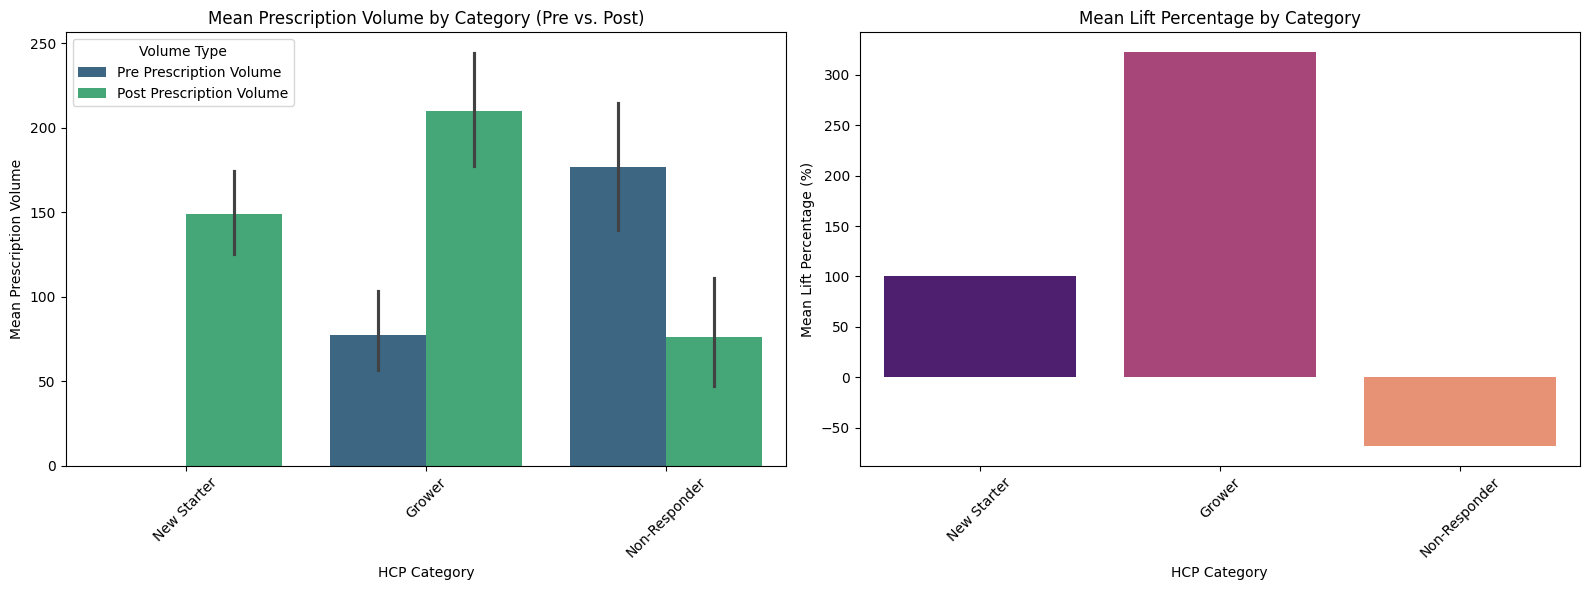

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = lift_df.melt(id_vars=['HCP_ID', 'Category'],
                         value_vars=['Pre Prescription Volume', 'Post Prescription Volume'],
                         var_name='Volume_Type', value_name='Prescription_Volume')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Mean Prescription Volume by Category and Type
sns.barplot(x='Category', y='Prescription_Volume', hue='Volume_Type', data=plot_data,
            palette='viridis', ax=axes[0])
axes[0].set_title('Mean Prescription Volume by Category (Pre vs. Post)')
axes[0].set_ylabel('Mean Prescription Volume')
axes[0].set_xlabel('HCP Category')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Volume Type')

# Plot 2: Lift Percentage by Category
sns.barplot(x='Category', y='Lift_Percentage', data=lift_df,
            palette='magma', ax=axes[1], errorbar=None) # errorbar=None to hide confidence intervals
axes[1].set_title('Mean Lift Percentage by Category')
axes[1].set_ylabel('Mean Lift Percentage (%)')
axes[1].set_xlabel('HCP Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Segmented Lift Analysis (Formatted Table)

#6b

In [ ]:
# Calculate total across all HCPs
total_hcps = lift_df['HCP_ID'].count()
total_mean_lift = lift_df['Lift_Percentage'].mean()

# Create a DataFrame for the 'Total' row
total_row = pd.DataFrame({
    'Category': ['Total'],
    'mean_pre_volume': [lift_df['Pre Prescription Volume'].mean()],
    'mean_post_volume': [lift_df['Post Prescription Volume'].mean()],
    'mean_lift_percentage': [total_mean_lift],
    'count': [total_hcps]
})

# Concatenate category_impact with the total row
formatted_table = pd.concat([category_impact, total_row], ignore_index=True)

# Select and rename columns as requested
formatted_table = formatted_table[['Category', 'count', 'mean_lift_percentage']]
formatted_table.columns = ['Category', 'HCPs', 'Avg Lift']

display(formatted_table.round(2))

,Category,HCPs,Avg Lift
0,Grower,25,322.75
1,New Starter,64,100.00
2,Non-Responder,46,-68.16
3,Total,135,83.95


### Visualizing Volume Growth by Category

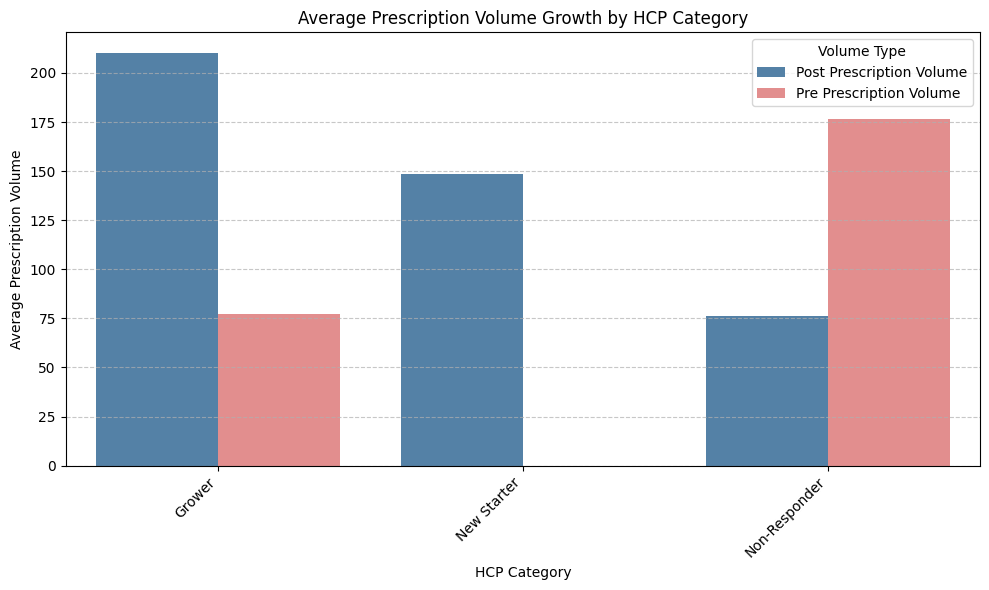

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group the plot_data by 'Category' and 'Volume_Type' and calculate the mean
mean_volume_by_category = plot_data.groupby(['Category', 'Volume_Type'])['Prescription_Volume'].mean().reset_index()

fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Prescription_Volume', hue='Volume_Type', data=mean_volume_by_category,
            palette={'Pre Prescription Volume': 'lightcoral', 'Post Prescription Volume': 'steelblue'})

plt.title('Average Prescription Volume Growth by HCP Category')
plt.xlabel('HCP Category')
plt.ylabel('Average Prescription Volume')
plt.legend(title='Volume Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Ques 7

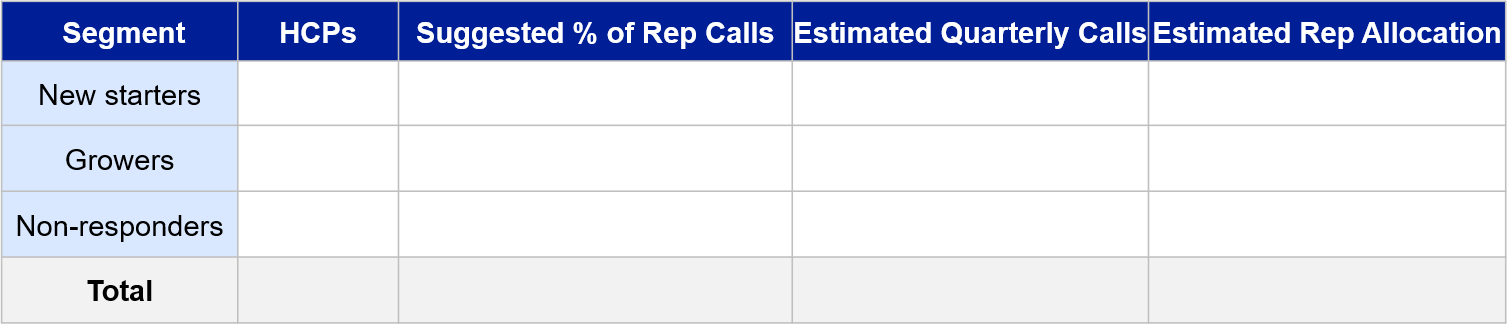


### Sales Representative Call Allocation

In [ ]:
# Define the parameters given by the user
calls_per_rep_per_day = 8
field_days_per_month = 20
total_sales_reps = 40

# Calculate total calls per rep per month
total_calls_per_rep_per_month = calls_per_rep_per_day * field_days_per_month
print(f"Total calls per rep per month: {total_calls_per_rep_per_month}")

# Calculate total organization calls per month
total_organization_calls_per_month = total_calls_per_rep_per_month * total_sales_reps
print(f"Total organization calls per month: {total_organization_calls_per_month}")

# Define allocation percentages for each category
allocation_percentages = {
    'Grower': 0.55,      # 55%
    'New Starter': 0.35, # 35%
    'Non-Responder': 0.10 # 10%
}

# Calculate allocated calls for each category
allocated_calls = {
    category: int(total_organization_calls_per_month * percentage)
    for category, percentage in allocation_percentages.items()
}

# Convert to DataFrame for better display
allocated_calls_df = pd.DataFrame(allocated_calls.items(), columns=['Category', 'Allocated Calls'])

display(allocated_calls_df)


Total calls per rep per month: 160
Total organization calls per month: 6400


,Category,Allocated Calls
0,Grower,3520
1,New Starter,2240
2,Non-Responder,640


### Visualizing Call Allocation

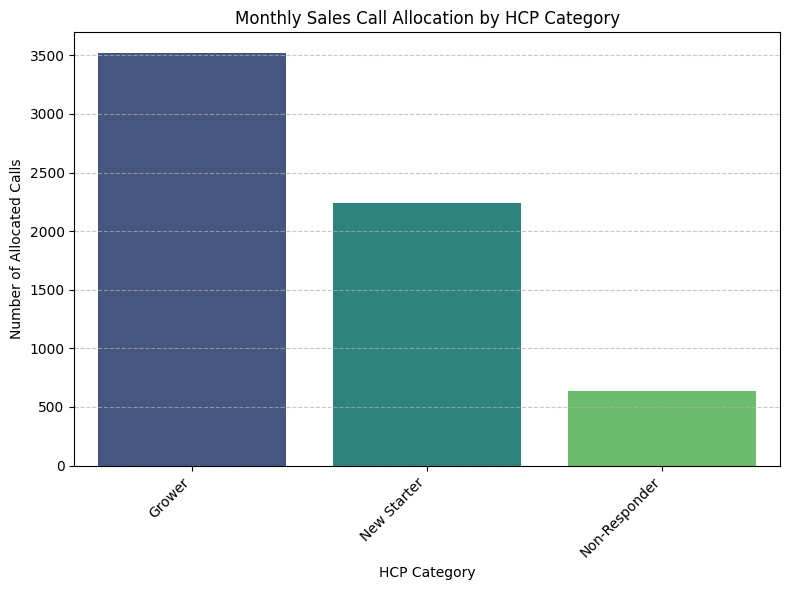

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(8, 6))
sns.barplot(x='Category', y='Allocated Calls', data=allocated_calls_df, palette='viridis', hue='Category', legend=False)
plt.title('Monthly Sales Call Allocation by HCP Category')
plt.xlabel('HCP Category')
plt.ylabel('Number of Allocated Calls')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Calls per HCP for Grower Segment

In [ ]:
# Get the total allocated calls for 'Grower'
grower_allocated_calls = allocated_calls['Grower']

# Get the count of HCPs in the 'Grower' category
grower_hcp_count = category_impact[category_impact['Category'] == 'Grower']['count'].iloc[0]

# Calculate calls per HCP for 'Grower' segment
calls_per_hcp_grower = grower_allocated_calls / grower_hcp_count

print(f"Total allocated calls for Growers: {grower_allocated_calls}")
print(f"Number of HCPs in Grower segment: {grower_hcp_count}")
print(f"Calls per HCP in Grower segment: {calls_per_hcp_grower:.2f}")


Total allocated calls for Growers: 3520
Number of HCPs in Grower segment: 25
Calls per HCP in Grower segment: 140.80


In [ ]:
import pandas as pd

SOURCE_FILE = "PrimeRx Datasets.xlsx" # Corrected file name
OUR_DRUG_ID = "DRG001"
WINDOW_DAYS = 90          # pre/post window for lift calc (Question 6)
GROWER_LIFT_THRESHOLD = 20  # % lift to qualify as a "Grower"

# ---------------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------------
alerts = pd.read_excel(SOURCE_FILE, sheet_name="Alerts")
sales = pd.read_excel(SOURCE_FILE, sheet_name="Sales")

# ---------------------------------------------------------------------
# 2. Question 6 - build the before/after lift table per HCP
# ---------------------------------------------------------------------
# Universe = every HCP with at least one positive alert
positive_alerts = alerts[alerts["Lab_Result"] == "Positive"].copy()
first_positive = (
    positive_alerts.groupby("HCP_ID")["Alert_Date"]
    .min()
    .reset_index()
    .rename(columns={"Alert_Date": "First_Positive_Alert"})
)

our_drug_sales = sales[sales["Drug_ID"] == OUR_DRUG_ID].copy()


def pre_post_volume(row):
    """Sum our-drug prescription volume in the 90 days before / after
    the HCP's first positive alert."""
    hcp_id = row["HCP_ID"]
    first_alert = row["First_Positive_Alert"]
    pre_start = first_alert - pd.Timedelta(days=WINDOW_DAYS)
    post_end = first_alert + pd.Timedelta(days=WINDOW_DAYS)

    hcp_sales = our_drug_sales[our_drug_sales["HCP_ID"] == hcp_id]

    pre_vol = hcp_sales.loc[
        (hcp_sales["Prescription_Date"] >= pre_start)
        & (hcp_sales["Prescription_Date"] < first_alert),
        "Prescription_Volume",
    ].sum()

    post_vol = hcp_sales.loc[
        (hcp_sales["Prescription_Date"] > first_alert)
        & (hcp_sales["Prescription_Date"] <= post_end),
        "Prescription_Volume",
    ].sum()

    return pd.Series({"Pre": pre_vol, "Post": post_vol})


lift_table = first_positive.join(first_positive.apply(pre_post_volume, axis=1))

lift_table["Lift_pct"] = lift_table.apply(
    lambda r: ((r["Post"] - r["Pre"]) / r["Pre"] * 100) if r["Pre"] > 0 else None,
    axis=1,
)


def assign_segment(row):
    if row["Pre"] == 0 and row["Post"] > 0:
        return "New starters"
    if row["Pre"] > 0 and row["Lift_pct"] is not None and row["Lift_pct"] >= GROWER_LIFT_THRESHOLD:
        return "Growers"
    return "Non-responders"


lift_table["Segment"] = lift_table.apply(assign_segment, axis=1)

segment_counts = (
    lift_table.groupby("Segment")["HCP_ID"].count().reindex(
        ["New starters", "Growers", "Non-responders"]
    )
)

print("Question 6 - Segment sizes")
print(segment_counts, "\n")

# ---------------------------------------------------------------------
# 3. Question 7 - field force capacity & allocation
# ---------------------------------------------------------------------
CALLS_PER_REP_PER_DAY = 8
FIELD_DAYS_PER_MONTH = 20
TOTAL_REPS = 40
MONTHS_PER_QUARTER = 3

total_quarterly_calls = (
    CALLS_PER_REP_PER_DAY * FIELD_DAYS_PER_MONTH * TOTAL_REPS * MONTHS_PER_QUARTER
)

# Strategic allocation weights (judgment call, informed by Q6 lift results:
# Growers show the strongest positive lift -> highest priority;
# New starters are newly converted and need reinforcement;
# Non-responders show negative lift -> lowest priority but not zero).
allocation_pct = {
    "New starters": 0.35,
    "Growers": 0.40,
    "Non-responders": 0.25,
}

rows = []
for segment, pct in allocation_pct.items():
    hcps = int(segment_counts[segment])
    quarterly_calls = round(total_quarterly_calls * pct)
    reps = round(TOTAL_REPS * pct)
    rows.append(
        {
            "Segment": segment,
            "HCPs": hcps,
            "Suggested % of Rep Calls": f"{pct * 100:.0f}%",
            "Estimated Quarterly Calls": quarterly_calls,
            "Estimated Rep Allocation": reps,
        }
    )

allocation_table = pd.DataFrame(rows)
total_row = pd.DataFrame(
    [
        {
            "Segment": "Total",
            "HCPs": allocation_table["HCPs"].sum(),
            "Suggested % of Rep Calls": "100%",
            "Estimated Quarterly Calls": allocation_table["Estimated Quarterly Calls"].sum(),
            "Estimated Rep Allocation": allocation_table["Estimated Rep Allocation"].sum(),
        }
    ]
)
allocation_table = pd.concat([allocation_table, total_row], ignore_index=True)

print(f"Total rep call capacity per quarter: {total_quarterly_calls:,} calls\n")
print("Question 7 - Rep allocation table")
print(allocation_table.to_string(index=False))


Question 6 - Segment sizes
Segment
New starters       64
Growers            25
Non-responders    125
Name: HCP_ID, dtype: int64 

Total rep call capacity per quarter: 19,200 calls

Question 7 - Rep allocation table
       Segment  HCPs Suggested % of Rep Calls  Estimated Quarterly Calls  Estimated Rep Allocation
  New starters    64                      35%                       6720                        14
       Growers    25                      40%                       7680                        16
Non-responders   125                      25%                       4800                        10
         Total   214                     100%                      19200                        40
